# Task 1: Linear Regression from Scratch (BGD)

36206.643689464094 88789.32291548022


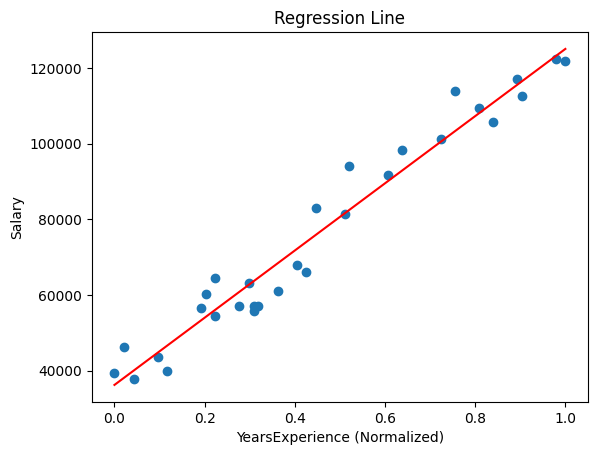

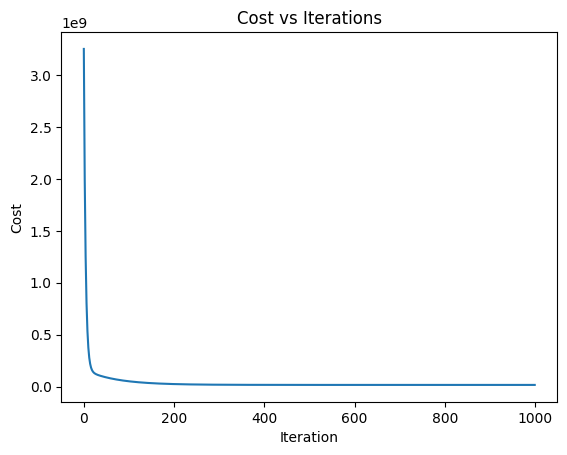

In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
data = pd.read_csv("Salary_Data.csv")

# Preprocessing
data = data.dropna()

X = data["YearsExperience"].values
y = data["Salary"].values

# Normalize (Min-Max)
X_min, X_max = X.min(), X.max()
X = (X - X_min) / (X_max - X_min)

# Initialize parameters
theta0 = 0.0
theta1 = 0.0
learning_rate = 0.1
iterations = 1000
m = len(y)

cost_history = []

# Gradient Descent
for _ in range(iterations):
    h = theta0 + theta1 * X
    error = h - y
    theta0 -= (learning_rate / m) * np.sum(error)
    theta1 -= (learning_rate / m) * np.sum(error * X)
    cost = (1 / (2 * m)) * np.sum(error ** 2)
    cost_history.append(cost)

print(theta0, theta1)

# Plot regression line
plt.scatter(X, y)
plt.plot(X, theta0 + theta1*X, color='red')
plt.xlabel("YearsExperience (Normalized)")
plt.ylabel("Salary")
plt.title("Regression Line")
plt.show()

# Plot cost
plt.plot(cost_history)
plt.title("Cost vs Iterations")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

# Task 2: Sklearn Linear Regression

MSE: 49830096.8559084
R2: 0.9024461774180497
Sklearn Intercept: 35687.77986711088 Coef: 88583.86403649117
Scratch  theta0: 36206.643689464094 theta1: 88789.32291548022


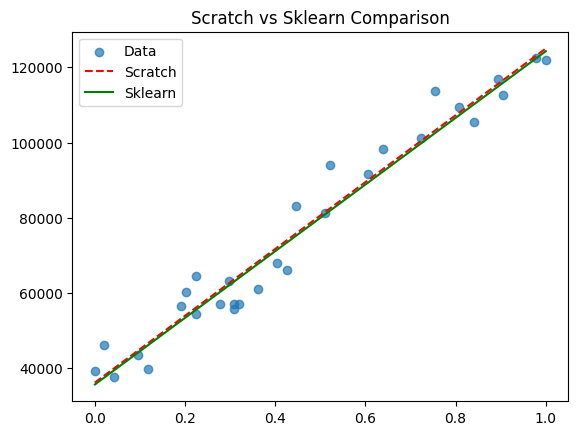

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# set input and target variable
data2 = pd.read_csv("Salary_Data.csv").dropna()
X2 = data2["YearsExperience"].values.reshape(-1, 1)
y2 = data2["Salary"].values
X2 = (X2 - X2.min()) / (X2.max() - X2.min())

# Split data
X_train, X_test, y_train, y_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

# Initialize model
model = LinearRegression()

# Fit model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate (MSE, R2)
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))
print("Sklearn Intercept:", model.intercept_, "Coef:", model.coef_[0])
print("Scratch  theta0:", theta0, "theta1:", theta1)

# Graphical comparison
X_line = np.linspace(0, 1, 100)
plt.scatter(X2, y2, alpha=0.7, label="Data")
plt.plot(X_line, theta0 + theta1 * X_line, color='red', linestyle='--', label="Scratch")
plt.plot(X_line, model.intercept_ + model.coef_[0] * X_line, color='green', label="Sklearn")
plt.legend()
plt.title("Scratch vs Sklearn Comparison")
plt.show()

# Task 3: Multivariate Linear Regression

MSE: 0.5558915986952442
R2: 0.575787706032451
   Feature  Coefficient
    MedInc     0.852382
 AveBedrms     0.371132
  HouseAge     0.122382
Population    -0.002298
  AveOccup    -0.036624
  AveRooms    -0.305116
 Longitude    -0.868927
  Latitude    -0.896635


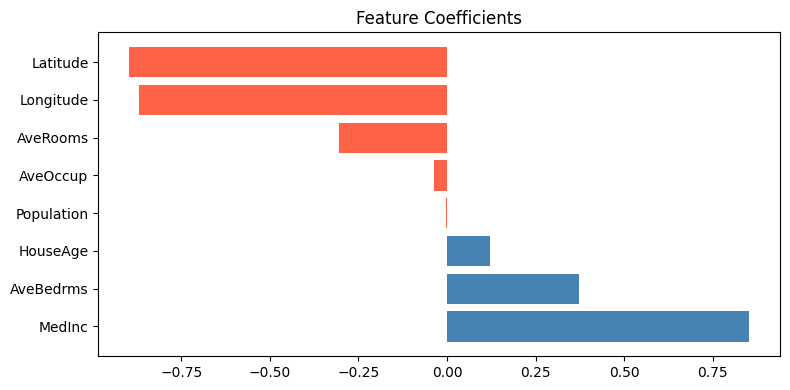

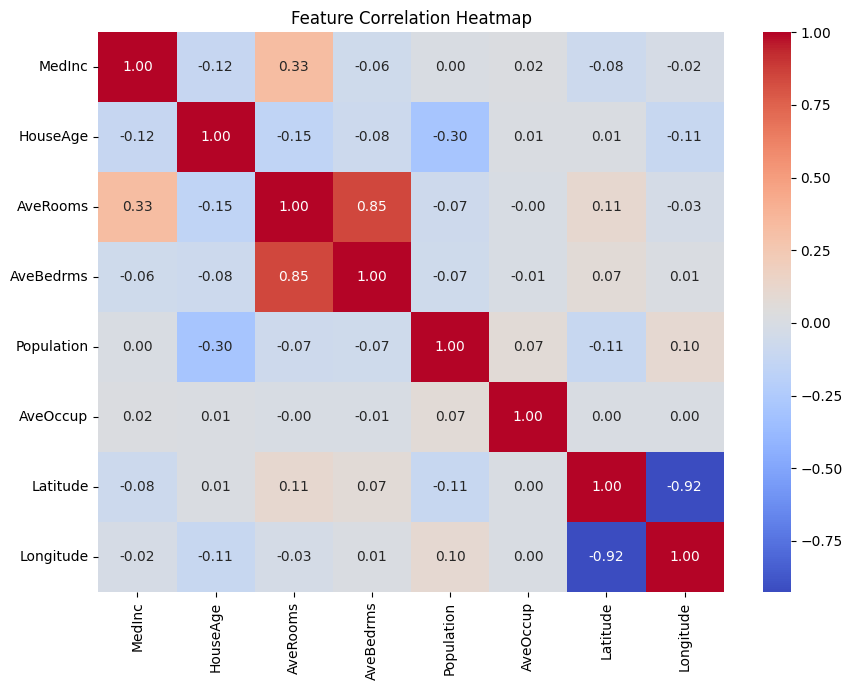

In [3]:
from sklearn.datasets import fetch_california_housing
from sklearn.preprocessing import StandardScaler
import seaborn as sns

# Load dataset
housing = fetch_california_housing()
X3 = pd.DataFrame(housing.data, columns=housing.feature_names)
y3 = housing.target

# Apply StandardScaler
scaler = StandardScaler()
X3_scaled = scaler.fit_transform(X3)

# Train-test split
X3_train, X3_test, y3_train, y3_test = train_test_split(X3_scaled, y3, test_size=0.2, random_state=42)

# Train LinearRegression
lr3 = LinearRegression()
lr3.fit(X3_train, y3_train)

# Predict and evaluate
y3_pred = lr3.predict(X3_test)
print("MSE:", mean_squared_error(y3_test, y3_pred))
print("R2:", r2_score(y3_test, y3_pred))

# Print coefficients
coef_df = pd.DataFrame({"Feature": housing.feature_names, "Coefficient": lr3.coef_})
coef_df = coef_df.sort_values("Coefficient", ascending=False)
print(coef_df.to_string(index=False))

# Coefficient bar chart
plt.figure(figsize=(8, 4))
colors = ['tomato' if c < 0 else 'steelblue' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.title("Feature Coefficients")
plt.tight_layout()
plt.show()

# Heatmap Analysis
plt.figure(figsize=(9, 7))
corr = pd.DataFrame(X3_scaled, columns=housing.feature_names).corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


# Task 4: Logistic Regression from Scratch

Accuracy: 0.9736379613356766
Precision: 0.958139534883721
Recall: 0.9716981132075472
F1: 0.9648711943793911
[[348   9]
 [  6 206]]


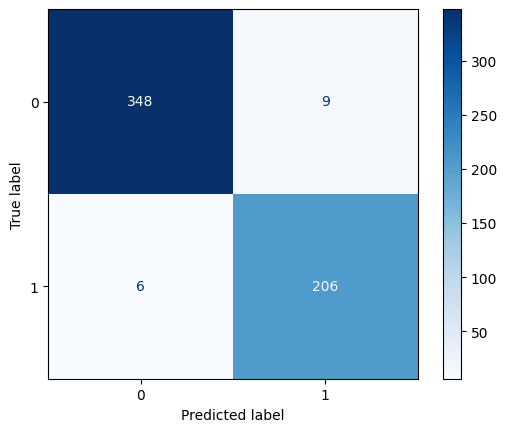

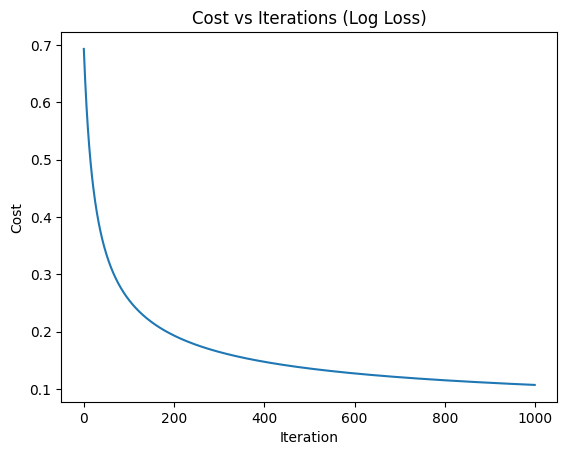

In [4]:

from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler

# Load dataset
cancer = load_breast_cancer()
X = cancer.data
# Malignant=1, Benign=0 (sklearn default: 0=malignant, 1=benign → flip)
y = 1 - cancer.target

# Apply StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)

m, n = X.shape
theta = np.zeros(n)
alpha = 0.01
iterations = 1000

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

cost_log = []
for _ in range(iterations):
    h = sigmoid(X @ theta)
    error = h - y
    theta -= (alpha / m) * (X.T @ error)
    eps = 1e-15
    cost = -(1/m) * np.sum(y * np.log(h+eps) + (1-y) * np.log(1-h+eps))
    cost_log.append(cost)

# Predictions
probs = sigmoid(X @ theta)
preds = (probs >= 0.5).astype(int)

# Metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

print("Accuracy:", accuracy_score(y, preds))
print("Precision:", precision_score(y, preds))
print("Recall:", recall_score(y, preds))
print("F1:", f1_score(y, preds))
print(confusion_matrix(y, preds))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

import matplotlib.pyplot as plt
cm = confusion_matrix(y, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap=plt.cm.Blues)
plt.show()

# Cost convergence
plt.plot(cost_log)
plt.title("Cost vs Iterations (Log Loss)")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.show()

# Task 5: Streamlit Churn App

## Training Script (run once)

In [5]:
import pandas as pd
import joblib

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Load data
data = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")

# Preprocess
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'], errors='coerce')
data = data.dropna()

data['Churn'] = data['Churn'].map({'Yes':1, 'No':0})

# Features
num_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
cat_features = ['Contract', 'InternetService']

X = data[num_features + cat_features]
y = data['Churn']

# Pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_features)
])

pipeline = Pipeline([
    ('preprocessing', preprocessor),
    ('model', LogisticRegression(max_iter=1000))
])

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#train
pipeline.fit(X_train, y_train)

print("Accuracy:", accuracy_score(y_test, pipeline.predict(X_test)))

# Save ONE file
joblib.dump(pipeline, "churn_model.pkl")
print("Saved churn_model.pkl")

Accuracy: 0.7853589196872779
Saved churn_model.pkl


# Streamlit App (app.py)

In [6]:
import streamlit as st
import pandas as pd
import joblib

# Load model
model = joblib.load("churn_model.pkl")

#set title
st.title("Customer Churn Predictor")

# Inputs
tenure = st.number_input("Tenure (months)", min_value=0, max_value=120, value=12)
monthly = st.number_input("Monthly Charges ($)", min_value=0.0, max_value=500.0, value=65.0)
total = st.number_input("Total Charges ($)", min_value=0.0, max_value=15000.0, value=780.0)
contract = st.selectbox("Contract", ["Month-to-month", "One year", "Two year"])
internet = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])

input_df = pd.DataFrame([{
    'tenure': tenure, 'MonthlyCharges': monthly,
    'TotalCharges': total, 'Contract': contract,
    'InternetService': internet
}])

# event listener
if st.button("Predict"):

    pred = model.predict(input_df)[0]
    prob_churn = model.predict_proba(input_df)[0][1]
    prob_stay = 1 - prob_churn

    if pred == 1:
        st.write("Customer will Churn")
        st.write("Probability of Churn:", prob_churn)
    else:
        st.write("Customer will Stay")
        st.write("Probability of Staying:", prob_stay)

2026-04-20 22:58:53.956 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 22:58:54.433 
  command:

    streamlit run /home/uzairmajeed/BS_SE/Semesters/Semester VI/AI-LAB/Lab11/venv/lib/python3.12/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-04-20 22:58:54.435 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 22:58:54.436 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 22:58:54.437 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 22:58:54.438 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-20 22:58:54.439 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mod